In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from statsmodels.formula.api import ols, logit
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

DATA_DIR = Path('../data')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

df = pd.read_csv(DATA_DIR / 'olist_clean.csv', parse_dates=[
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
])

# Drop rows missing review scores for this analysis
df_reg = df.dropna(subset=['review_score', 'delay_days', 'processing_days', 'freight_value', 'price']).copy()
df_reg['freight_ratio'] = df_reg['freight_value'] / df_reg['price']

print(f"Regression dataset: {df_reg.shape}")

Regression dataset: (109820, 23)


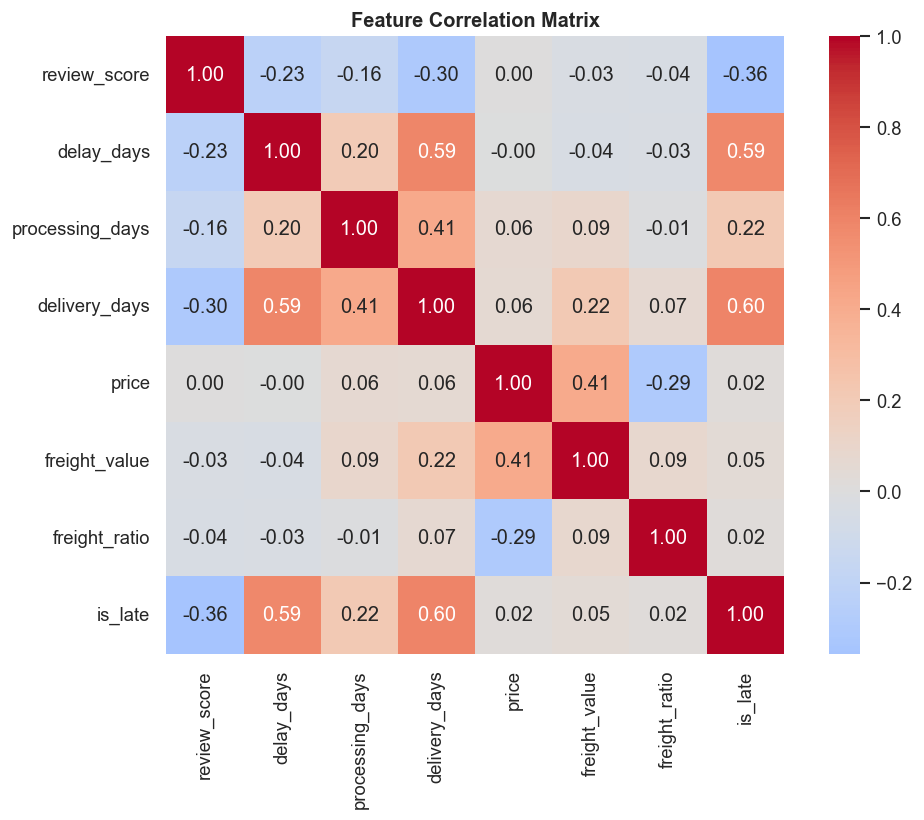

In [2]:
# CORRELATION HEATMAP
features = ['review_score', 'delay_days', 'processing_days', 
            'delivery_days', 'price', 'freight_value', 'freight_ratio', 'is_late']

corr = df_reg[features].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, ax=ax, square=True)
ax.set_title('Feature Correlation Matrix', fontweight='bold')
plt.tight_layout()
plt.savefig('../visuals/07_correlation_heatmap.png', dpi=120)
plt.show()

In [3]:
# LINEAR REGRESSION: PREDICTING REVIEW SCORE
formula = 'review_score ~ delay_days + processing_days + freight_ratio + price + is_late'
model_ols = ols(formula, data=df_reg).fit()
print(model_ols.summary())

                            OLS Regression Results                            
Dep. Variable:           review_score   R-squared:                       0.135
Model:                            OLS   Adj. R-squared:                  0.135
Method:                 Least Squares   F-statistic:                     3424.
Date:                Thu, 19 Mar 2026   Prob (F-statistic):               0.00
Time:                        16:54:05   Log-Likelihood:            -1.8065e+05
No. Observations:              109820   AIC:                         3.613e+05
Df Residuals:                  109814   BIC:                         3.614e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           4.2758      0.009    4

In [4]:
# LOGISTIC REGRESSION: PREDICTING LATE DELIVERY
formula_logit = 'is_late ~ processing_days + freight_ratio + price'
model_logit = logit(formula_logit, data=df_reg).fit()
print(model_logit.summary())

Optimization terminated successfully.
         Current function value: 0.225192
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                is_late   No. Observations:               109820
Model:                          Logit   Df Residuals:                   109816
Method:                           MLE   Df Model:                            3
Date:                Thu, 19 Mar 2026   Pseudo R-squ.:                 0.06091
Time:                        16:54:42   Log-Likelihood:                -24731.
converged:                       True   LL-Null:                       -26335.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          -3.2771      0.022   -148.906      0.000      -3.320      -3.234
processing_day

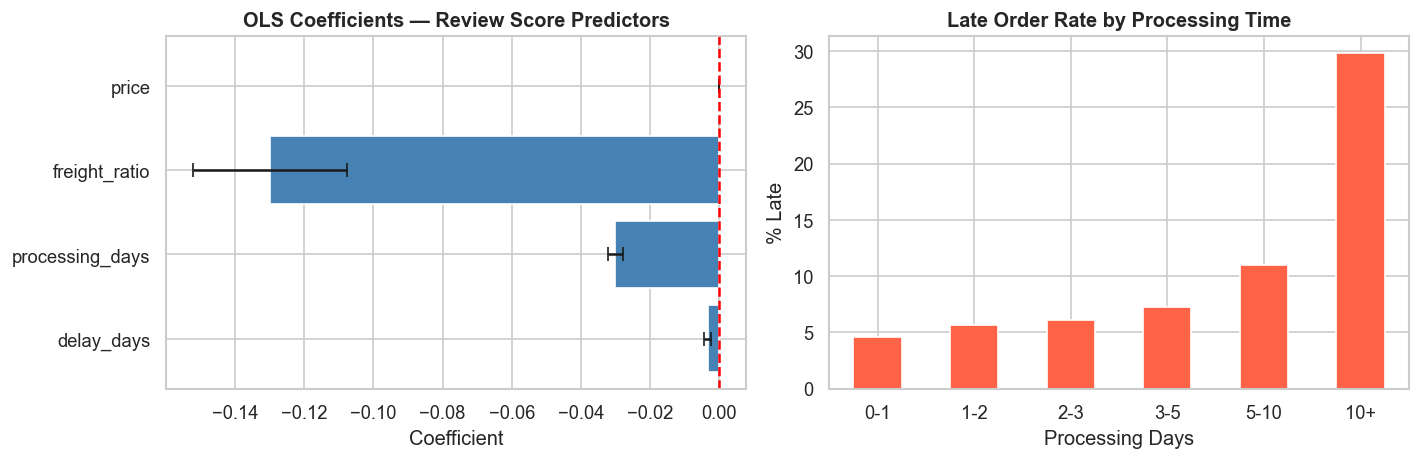

In [5]:
# VISUALIZING KEY REGRESSION FINDINGS
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# OLS coefficients (excluding intercept and is_late)
coefs = model_ols.params[1:]
errors = model_ols.conf_int()[1:].apply(lambda x: x[1] - x[0], axis=1) / 2
coefs = coefs.drop('is_late')
errors = errors.drop('is_late')

axes[0].barh(coefs.index, coefs.values, xerr=errors.values, color='steelblue', capsize=4)
axes[0].axvline(0, color='red', linestyle='--')
axes[0].set_title('OLS Coefficients — Review Score Predictors', fontweight='bold')
axes[0].set_xlabel('Coefficient')

# Late orders by processing days bucket
df_reg['processing_bucket'] = pd.cut(df_reg['processing_days'], 
                                      bins=[0,1,2,3,5,10,125], 
                                      labels=['0-1','1-2','2-3','3-5','5-10','10+'])
late_by_processing = df_reg.groupby('processing_bucket', observed=True)['is_late'].mean() * 100
late_by_processing.plot(kind='bar', ax=axes[1], color='tomato', edgecolor='white')
axes[1].set_title('Late Order Rate by Processing Time', fontweight='bold')
axes[1].set_xlabel('Processing Days')
axes[1].set_ylabel('% Late')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('../visuals/08_regression_findings.png', dpi=120)
plt.show()

In [6]:
# NOTEBOOK 03 SUMMARY

print("""
Notebook 03 — Regression Analysis Complete
===========================================
OLS — Predicting Review Score (R²=0.135):
  · is_late:          -1.77  (strongest predictor — being late costs ~2 stars)
  · processing_days:  -0.030 (each extra day to carrier hurts satisfaction)
  · freight_ratio:    -0.130 (high shipping cost relative to price hurts)
  · price:             not significant (p=0.067)

Logit — Predicting Late Delivery:
  · processing_days:  +0.136 (biggest driver of late delivery risk)
  · freight_ratio:    +0.230 (bulkier/heavier items more likely late)
  · price:            +0.0003 (small but significant)

Ready for Notebook 04: Seller Clustering
""")


Notebook 03 — Regression Analysis Complete
OLS — Predicting Review Score (R²=0.135):
  · is_late:          -1.77  (strongest predictor — being late costs ~2 stars)
  · processing_days:  -0.030 (each extra day to carrier hurts satisfaction)
  · freight_ratio:    -0.130 (high shipping cost relative to price hurts)
  · price:             not significant (p=0.067)

Logit — Predicting Late Delivery:
  · processing_days:  +0.136 (biggest driver of late delivery risk)
  · freight_ratio:    +0.230 (bulkier/heavier items more likely late)
  · price:            +0.0003 (small but significant)

Ready for Notebook 04: Seller Clustering

